# Tonights Best

### Run the code:
Press play on the below cell that says "Show code," this will install the necessary libraries, and define the dome_scheduler class to make the system runnable.

**Do not modify the code without knowing what it does.**

In [ ]:
# @title

# Install necessary libs
!pip install astroplan astroquery -q

from astropy.coordinates import EarthLocation, Latitude, Longitude
from astropy.time import Time
import astropy.units as units
from astroplan import Observer, FixedTarget
from astroquery.simbad import Simbad
from datetime import datetime
from zoneinfo import ZoneInfo
from astropy.coordinates import SkyCoord
import pandas as pd
import warnings
from IPython.display import display, Markdown
import time

class dome_scheduler:
  #32°26'32.3"N 110°47'20.5"W - Schulman Dome coords from Google Maps
  def __init__(self):
    site_name = "Mount Lemmon"
    elevation = 9171
    lat = Latitude('32d26m32.3s')
    lon = Longitude('-110d47m20.5s')


    self.location = EarthLocation(lat=lat, lon=lon, height=elevation*units.m)
    self.observer = Observer(location=self.location, name=site_name)

    # Parameters for filtering
    self.start_time = None
    self.end_time = None
    self.max_magnitude = None
    self.min_altitude = None
    self.hide_objects_below_min_altitude = None
    self.show_all_acquired_targets = None
    self.sort_by= None

    print(f'Observer initialized at 32°26`32.3"N 110°47`20.5"W')

    try:
      ngc_url = "https://raw.githubusercontent.com/mattiaverga/OpenNGC/master/database_files/NGC.csv"
      self.openngc_df = pd.read_csv(ngc_url, sep=';')
      print("OpenNGC catalog loaded successfully")
      #print(self.openngc_df.columns.tolist())
    except Exception as e:
      print(f"Could not load OpenNGC catalog: {e}")
      self.openngc_df = None


  def calculate_meridian_transit(self, target):
    # This is the time when the object peaks in the sky.
    # This is used for determining the default order of objects.
    transit_time = self.observer.target_meridian_transit_time(
        self.start_time,
        target,
        which='next'
    )
    return transit_time

  def _azimuth_to_compass(self, az_deg):
    # This compass defines more precise directions for pointing out where in the sky an object is.
    # Knowing the direction, and the altitude gives a general idea.
    dirs = ['N','NNE','NE','ENE','E','ESE','SE','SSE',
            'S','SSW','SW','WSW','W','WNW','NW','NNW']
    # It splits up the
    idx = int((az_deg / 22.5) + 0.5) % 16
    return dirs[idx]

  def map_category(self, otype):
      types = [t.strip() for t in otype.split('|')]

      if 'GlC' in types:
          return 'Globular Clusters'
      elif 'OpC' in types:
          return 'Open Clusters'
      elif 'Pl' in types:
          return 'Planet'
      elif 'PN' in types:
          return 'Planetary Nebulae'
      elif 'SNR' in types:
          return 'Supernova Remnants'
      elif any(t in types for t in ['HII', 'SFR']):
          return 'Emission Nebulae'
      elif any(t in types for t in ['G', 'LSB', 'bCG', 'SBG', 'EmG', 'AGN', 'SyG', 'rG', 'GiP', 'GiG', 'GiC']):
          return 'Galaxies'
      elif 'RNe' in types:
          return 'Reflection Nebulae'
      else:
          return 'Other'

  #---------------------------------------------------------------------------
  def plot_observing_chart(self, schedule_objects):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)  # clockwise so E is on the right, like a compass
    ax.set_ylim(90, 0)          # zenith (alt=90) at center, horizon (alt=0) at edge
    ax.set_yticks([0, 30, 60, 90])
    ax.set_yticklabels(['0°', '30°', '60°', 'Zenith'])
    ax.set_title("Tonight's Observing Chart (at midpoint)", pad=20)

    category_colors = {
        'Globular Clusters':  'gold',
        'Open Clusters':      'skyblue',
        'Galaxies':           'orchid',
        'Planetary Nebulae':  'mediumseagreen',
        'Planet':             'orangered',
        'Supernova Remnants': 'crimson',
        'Emission Nebulae':   'coral',
        'Reflection Nebulae': 'royalblue',
        'Other':              'gray'
    }

    used_cats = set()
    for obj, category in schedule_objects:
        theta = np.radians(obj['azimuth'])
        r = 90 - obj['altitude']
        color = category_colors.get(category, 'gray')
        ax.scatter(theta, r, s=60, color=color, zorder=3, edgecolor='black', linewidth=0.5)
        ax.annotate(obj['name'], (theta, r), textcoords="offset points", xytext=(5, 5), fontsize=8)
        used_cats.add(category)

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=cat)
               for cat, c in category_colors.items() if cat in used_cats]
    ax.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

    plt.tight_layout()
    plt.show()

  def retrieve_object_info(self, name, coord=None):
    info = {
        'common_name': None,
        'constellation': None,
        'distance_ly': None,
        'nasa_url': None
    }

    if name.startswith('M'):
      num = name[1:]
      info['nasa_url'] = f"https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-{num}/"

    elif name.startswith('NGC') or name.startswith('IC'):
      encoded = name.replace(' ', '+')
      info['nasa_url'] = f"https://simbad.u-strasbg.fr/simbad/sim-id?Ident={encoded}"


    if coord is not None:
      info['constellation'] = coord.get_constellation()
    else:
      try:
        target = FixedTarget.from_name(name)
        info['constellation'] = target.coord.get_constellation()
      except Exception as e:
        print(f" Could not retrieve constellation for {name}: {e}")


    if self.openngc_df is not None and name.startswith('M'):
      try:
        messier_num = int(name[1:])
        row = self.openngc_df[pd.to_numeric(self.openngc_df['M'], errors='coerce') == messier_num]

        if not row.empty:
          common = row.iloc[0].get('Common names', None)
          if common and str(common) not in ('', 'nan', '--'):
            info['common_name'] = str(common).split(',')[0].strip()

          if 'Dist' in self.openngc_df.columns:
            dist = row.iloc[0].get('Dist', None)
            if dist and str(dist) not in ('', 'nan', '--'):
              info['distance_ly'] = int(float(dist) * 3_261_564)

      except Exception as e:
        print(f"Could not retrieve OpenNGC data for {name}: {e}")

    return info
  #--------------------------------------------------------------------------------

  def _get_ngc_supplements(self):
    if self.openngc_df is None:
        return []

    valid_types = {'GCl', 'OCl', 'G', 'PN', 'Pl', 'SNR', 'HII', 'RNe'}

    # Exclude objects that already have a Messier number
    no_messier = self.openngc_df['M'].isna() | (self.openngc_df['M'].astype(str).str.strip() == '')

    valid_type_mask = self.openngc_df['Type'].isin(valid_types)

    # Filter by magnitude
    numeric_mag = pd.to_numeric(self.openngc_df['V-Mag'], errors='coerce')
    # tighter mag to limit retrieval
    bright_enough = numeric_mag <= self.max_magnitude

    # filter by dec - UNUSED, needs tuning, currently retrieves nothing if used.
    numeric_dec = pd.to_numeric(self.openngc_df['Dec'], errors='coerce')
    visible_dec = numeric_dec >= -50

    filtered = self.openngc_df[no_messier & valid_type_mask & bright_enough]# & visible_dec]

    # Convert "NGC0891" or "IC0434" format to "NGC 891" / "IC 434"
    names = []
    for raw in filtered['Name']:
        raw = str(raw).strip()
        try:
          if raw.startswith('NGC'):
              names.append('NGC ' + str(int(raw[3:])))
          elif raw.startswith('IC'):
              names.append('IC ' + str(int(raw[2:])))
        except ValueError:
          pass

    print(f"OpenNGC supplement: {len(names)} additional candidates after filtering")
    return names


  def retrieve_objects(self, target_names: list):
    warnings.filterwarnings("ignore")
    valid_targets = []

    # get magnitude, type, and distance from simbad
    simbad = Simbad()
    simbad.add_votable_fields('mesdistance') # Can also retrieve 'V' and 'otypes' for magnitude and object type respectively
    distance_lookup = {}
    print(f"Querying SIMBAD for distances ({len(target_names)} objects)...")
    try:
      batch_result = simbad.query_objects(target_names)
      if batch_result is not None:
        #print(batch_result.colnames)
        seen = set()
        for row in batch_result:
          matched = str(row['main_id']).replace(' ', '').upper()
          if matched in seen:
            continue
          seen.add(matched)
          raw_dist = row['mesdistance.dist']
          raw_unit = str(row['mesdistance.unit']).strip().lower()
          if str(raw_dist) not in ('','--','nan') and not (hasattr(raw_dist, 'mask') and raw_dist.mask):
            dist_val = float(raw_dist)
            if raw_unit == 'kpc':
              distance_lookup[matched] = int(dist_val * 3_261.564)
            elif raw_unit == 'mpc':
              distance_lookup[matched] = int(dist_val * 3_261_564)
      print(f"Distance data retrieved for {len(distance_lookup)} objects")
    except Exception as e:
      print(f"Could not retrieve distance data: {e}")

    coord_lookup = {}
    if self.openngc_df is not None:
      for name in target_names:
          try:
              row = None
              if name.startswith('M'):
                messier_num = int(name[1:])
                rows = self.openngc_df[pd.to_numeric(self.openngc_df['M'], errors='coerce') == messier_num]
                if not rows.empty:
                  row = rows.iloc[0]
              elif name.startswith('NGC'):
                ngc_num = int(name.split()[-1])
                rows = self.openngc_df[self.openngc_df['Name']==f"NGC{ngc_num:04d}"]
                if not rows.empty:
                  row = rows.iloc[0]
              elif name.startswith('IC'):
                ic_num = int(name.split()[-1])
                rows = self.openngc_df[self.openngc_df['Name']==f"IC{ic_num:04d}"]
                if not rows.empty:
                  row = rows.iloc[0]

              if row is not None:
                ra = str(row['RA'])
                dec = str(row['Dec'])
                if ra not in ('', 'nan', '--') and dec not in ('', 'nan', '--'):
                  coord = SkyCoord(ra=ra, dec=dec, unit=(units.hourangle, units.deg))
                  coord_lookup[name] = coord
          except Exception as e:
              print(f"Could not retrieve coordinates for {name}: {e}")
              pass
    print(f"Coordinates pre-loaded for {len(coord_lookup)}/{len(target_names)} objects from OpenNGC")

    for name in target_names:
      try:
        #target = FixedTarget.from_name(name)
        if name in coord_lookup:
          target = FixedTarget(coord=coord_lookup[name], name=name)
        else:
          target = FixedTarget.from_name(name)

        transit_time = self.calculate_meridian_transit(target)

        midpoint_time = self.start_time + (self.end_time - self.start_time) / 2

        altaz = self.observer.altaz(midpoint_time, target)
        altaz_start = self.observer.altaz(self.start_time, target)
        direction = self._azimuth_to_compass(altaz.az.deg)

        if altaz.alt.deg < 10:
          continue

        v_mag = 0.0
        #result_table = simbad.query_object(name)
        obj_type = 'Unknown'
        #distance_ly = None

        if self.openngc_df is not None:
          ngc_row = None
          try:
              if name.startswith('M'):
                messier_num = int(name[1:])
                rows = self.openngc_df[pd.to_numeric(self.openngc_df['M'], errors='coerce') == messier_num]
                if not rows.empty:
                  ngc_row = rows.iloc[0]
              elif name.startswith('NGC'):
                ngc_num = int(name[1:])
                rows = self.openngc_df[self.openngc_df['Name']==f"NGC{ngc_num:04d}"]
                if not rows.empty:
                  ngc_row = rows.iloc[0]
              elif name.startswith('IC'):
                ic_num = int(name[1:])
                rows = self.openngc_df[self.openngc_df['Name']==f"IC{ic_num:04d}"]
                if not rows.empty:
                  ngc_row = rows.iloc[0]
          except Exception:
            pass

          if ngc_row is not None:
            ngc_mag = ngc_row.get('V-Mag', None)
            if ngc_mag and str(ngc_mag) not in ('', 'nan', '--'):
              v_mag = float(ngc_mag)

            ngc_type_map = {
                'GCl': 'GlC',
                'OCl': 'OpC',
                'G':   'G',
                'Pl': 'Pl',
                'PN':  'PN',
                'SNR': 'SNR',
                'HII': 'HII',
                'RNe': 'RNe',
            }
            mapped = ngc_type_map.get(str(ngc_row.get('Type', '')))
            if mapped:
                obj_type = mapped
        lookup_key = name.replace(' ', '').upper()
        distance_ly = distance_lookup.get(lookup_key)

        if v_mag > self.max_magnitude:
          continue

        if self.hide_objects_below_min_altitude and altaz.alt.deg < self.min_altitude.value:
          continue
        valid_targets.append({
            'name': name,
            'altitude': altaz.alt.deg,
            'azimuth': altaz.az.deg,
            'alt_start': altaz_start.alt.deg,
            'transit': transit_time.iso,
            'magnitude': v_mag,
            'otype': obj_type,
            'distance_ly': distance_ly,
            'coord': coord_lookup.get(name),
            'direction': direction
        })

        #df = result_table.to_pandas()
        #print(list(df.columns))

      except Exception as e:
        print(f"Could not resolve target {name}: {type(e).__name__}: {e}")

    buckets = {}
    for obj in valid_targets:
      #print(f"{obj['name']:<6} | otype: {obj['otype']:<30} | alt: {obj['altitude']:.1f}°")
      category = self.map_category(obj['otype'])
      buckets.setdefault(category, []).append(obj)

    category_icons = {
    'Globular Clusters':  '✨',
    'Open Clusters':      '⭐',
    'Galaxies':           '🌌',
    'Planetary Nebulae':  '🪐',
    'Planet':             '🌍',
    'Supernova Remnants': '💥',
    'Emission Nebulae':   '🌫️',
    'Reflection Nebulae': '🔵',
    'Other':              '🔭'
}


    az_tz = ZoneInfo("America/Phoenix")

    #====================== BUILD SUGGESTIONS =================================
    # Build observing schedule
    top5_by_category = {}
    for category, objects in buckets.items():
        objects.sort(key=lambda x: (-x['altitude'], x['magnitude']))
        top5_by_category[category] = objects[:5]

    SCHEDULE_LIMIT = 10

    category_order = [c for c in top5_by_category.keys() if c != 'Galaxies']
    if 'Galaxies' in top5_by_category:
        category_order.append('Galaxies')

    category_pools = {
        cat: sorted(objs, key=lambda x: x['magnitude'] if x['magnitude'] != 0.0 else 99)
        for cat, objs in top5_by_category.items()
    }
    category_indices = {cat: 0 for cat in category_order}

    schedule_objects = []
    used_names = set()

    for cat in category_order:
        pool = category_pools[cat]
        if pool:
            obj = pool[0]
            schedule_objects.append((obj, cat))
            used_names.add(obj['name'])
            category_indices[cat] = 1

    remaining = SCHEDULE_LIMIT - len(schedule_objects)
    made_progress = True
    while remaining > 0 and made_progress:
        made_progress = False
        for cat in category_order:
            if remaining <= 0:
                break
            pool = category_pools[cat]
            idx = category_indices[cat]
            if idx < len(pool):
                obj = pool[idx]
                category_indices[cat] = idx + 1
                if obj['name'] not in used_names:
                    schedule_objects.append((obj, cat))
                    used_names.add(obj['name'])
                    remaining -= 1
                    made_progress = True

    # Sort final list chronologically by transit time
    if (self.sort_by).lower() == "transit":
      schedule_objects.sort(key=lambda x: x[0]['transit'])
    elif (self.sort_by).lower() == "alt_mid":
      schedule_objects.sort(key=lambda x: -x[0]['altitude'])
    elif (self.sort_by).lower() == "alt_start":
      schedule_objects.sort(key=lambda x: -x[0]['alt_start'])
    elif (self.sort_by).lower() == "magnitude":
      schedule_objects.sort(key=lambda x: x[0]['magnitude'])
    else:
      print(f"Invalid sort string entered, defaulting to transit time (accepted values: 'transit', 'alt_mid', 'alt_start')")
      schedule_objects.sort(key=lambda x: x[0]['transit'])

    # PLOT
    self.plot_observing_chart(schedule_objects)


    #============================= HEADER ============================

    md_lines = ["# 🔭 Tonight's Best Targets\n\n"]

    md_lines.append("\n---\n## Recommended Observing\n")
    midpoint_time = (self.start_time + (self.end_time - self.start_time) / 2).to_datetime(timezone=ZoneInfo("UTC"))
    UTC_start = self.start_time.to_datetime(timezone=ZoneInfo("UTC"))
    local_starttime = UTC_start.astimezone(az_tz)
    local_midpoint = midpoint_time.astimezone(az_tz)
    local_start = local_starttime.strftime("%H:%M:%S")
    local_mid = local_midpoint.strftime("%H:%M:%S")
    md_lines.append(f"| # | Object | Category  | Magnitude | Direction| Distance | Altitude at {local_start} | Altitude at {local_mid} | Transit Time | Constellation | Info | Fun Facts |")
    md_lines.append("|---|--------|-----------|-----------|----------|----|------------|------------|-----------|---------------|------|-----------|")

    for i, (obj, category) in enumerate(schedule_objects, 1):
        info = self.retrieve_object_info(obj['name'], coord=obj.get('coord'))
        icon = category_icons.get(category, '🔭')
        #utc_dt = Time(obj['transit']).to_datetime(timezone=ZoneInfo("UTC"))
        #local_dt = utc_dt.astimezone(az_tz)
        #time_str = local_dt.strftime("%H:%M")
        utc_datetime = Time(obj['transit']).to_datetime(timezone=ZoneInfo("UTC"))
        local_datetime = utc_datetime.astimezone(az_tz)
        local_str = local_datetime.strftime("%H:%M:%S")
        link = f"[Info]({info['nasa_url']})" if info.get('nasa_url') else "N/A"
        query = f"{obj['name'].replace(' ', '+')}+astronomy+fun+facts"
        fun_facts_link = f"[Fun Facts](https://www.google.com/search?q={query})"
        mag_str = f"{obj['magnitude']:.1f}" if obj['magnitude'] != 0.0 else "N/A"
        dist = f"{obj['distance_ly']:,} ly" if obj.get('distance_ly') else "N/A"
        #common = info.get('common_name') or "—"
        md_lines.append(
            f"| {i} | **{obj['name']}** | {icon}{category} | `{mag_str}` | {obj['direction']} | `{dist}` | `{obj['alt_start']:.1f}°` | `{obj['altitude']:.1f}°` | {local_str} | {info.get('constellation', 'N/A')} | {link} | {fun_facts_link} |"
        )
    md_lines.append("\n\n\n")


    #============================= REGULAR LIST ============================
    if self.show_all_acquired_targets:
      md_lines.append(f"\n\n# --- All Retrieved Targets ---\n\n")
      for category, top5 in top5_by_category.items():
        icon = category_icons.get(category, '🔭')

        md_lines.append(f"## {icon} {category}")
        md_lines.append("---")

        for obj in top5:
          info = self.retrieve_object_info(obj['name'], coord=obj.get('coord'))
          utc_datetime = Time(obj['transit']).to_datetime(timezone=ZoneInfo("UTC"))
          local_datetime = utc_datetime.astimezone(az_tz)
          local_str = local_datetime.strftime("%Y-%m-%d %H:%M:%S")
          mag_str = f"{obj['magnitude']:.1f}" if obj['magnitude'] != 0.0 else "N/A"
          common = f" — *{info['common_name']}*" if info.get('common_name') else ""
          dist = f"{obj['distance_ly']:,} ly" if obj.get('distance_ly') else "N/A"
          alt_warning = " ⚠️ *Below ideal altitude*" if obj['altitude'] < self.min_altitude.value else ""
          link = f"[More Info]({info['nasa_url']})" if info.get('nasa_url') else "N/A"
          query = f"{obj['name'].replace(' ', '+')}+astronomy+fun+facts"
          fun_facts_link = f"[Fun Facts](https://www.google.com/search?q={query})"


          md_lines.append(f"### **{obj['name']}**{common}{alt_warning}")
          md_lines.append(f"- **Magnitude:** `{mag_str}` | **Alt (Start):** `{obj['alt_start']:.1f}°` | **Alt (Midpoint):** `{obj['altitude']:.1f}°` | **Transit:** `{local_str}`")
          md_lines.append(f"- **Constellation:** {info.get('constellation', 'N/A')}")
          md_lines.append(f"- **Distance:** {dist}")
          md_lines.append(f"- **Database Info:** {link}\n")
          md_lines.append(f"- **Fun Facts:** {fun_facts_link}\n")

    display(Markdown('\n'.join(md_lines)))
    return valid_targets

  def view_sky(self, start_iso: str, end_iso: str, target_names: None, hide_objects_below_min_altitude = False, min_altitude = 25, max_magnitude = 12.0, show_all_acquired_targets = False, sort_by = "Transit"):
    az_tz = ZoneInfo("America/Phoenix")

    # Handle start and end as AZ time
    start = datetime.strptime(start_iso, "%Y-%m-%d %H:%M:%S").replace(tzinfo=az_tz)
    end = datetime.strptime(end_iso, "%Y-%m-%d %H:%M:%S").replace(tzinfo=az_tz)

    self.start_time = Time(start)
    self.end_time = Time(end)
    self.min_altitude = min_altitude * units.deg
    self.max_magnitude = max_magnitude
    self.hide_objects_below_min_altitude = hide_objects_below_min_altitude
    self.show_all_acquired_targets = show_all_acquired_targets
    self.sort_by = sort_by
    if target_names is None:
        # Generates strings for Messier and NGC catalog
        messier = [f"M{i}" for i in range(1, 111)]
        ngc_supplement = self._get_ngc_supplements()
        target_names = messier + ngc_supplement

    print(f"Observing Window: {start} - {end}")
    schedule = self.retrieve_objects(target_names)
    return schedule


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.0 MB/s eta 0:00:00


# VIEWING THE OUTPUT

### INTERPRETING THE OUTPUT

**Categories**:

    'Globular Clusters':  '✨',
    'Open Clusters':      '⭐',
    'Galaxies':           '🌌',
    'Planetary Nebulae':  '🪐',
    'Supernova Remnants': '💥',
    'Emission Nebulae':   '🌫️',
    'Reflection Nebulae': '🔵',
    'Other':              '🔭'

The output will show an object's following traits where applicable:
- Magnitude
- Altitude at start (Altitude at the beginning of observing)
- Altitude at midpoint (This is its altitude halfway through the observing window).
  - *Knowing how high it is at the start and how high it is halfway through observing describes its trajectory/visibility for the night.*
- Transit (This is the time when it peaks in the sky)
- Constellation
- Distance
- More Info (This is a link to either an object's profile on Nasa [for most messier objects] or SIMBAD [for NGC])
- Fun facts (Formatted google search query).

---

***Note the system is not perfect; measurements in this database may differ from online sources, or some data may be missing.***

---

# Enter Tonight's Details for Observing

### **REQUIRED PARAMETERS**
**You must enter the start and end time in 24 hour UTC format: YYYY-MM-DD HH:MM:SS**

***THIS WILL BE INTERPRETED AS AZ TIME.***

Example: `"2026-06-01 20:00:00"` -- This is June 1st 8:00 PM.

- **start_iso**: This parameter is the start time for observing.

- **end_iso**: This parameter is the end time for observing.

### Optional Parameters:
- **show_all_acquired_targets**: False by default. Setting this to true will output the top 5 (at most) best targets in each category that the system identified.
- **hide_objects_below_min_altitude**: True by default. If set to false, it will not hide objects that are below the `min_altitude`, but may show more categories. **REQUIRES `show_all_acquired_targets` to be True**.
- **min_altitude**: This is the minimum altitude for filtering objects that are too low to view in the telescope. Default 30, currently set to 25.
- **max_magnitude**: This is the maximum magnitude for filtering objects. Anything above default (12) will be excluded.
- **target_names**: `None` by default. Can be changed to an array named `targets` to use a premade list (faster retrieval).
- **sort_by**: Defaults to `transit`, this is the sort order of the Recommended Observing table. It accepts:
  - `transit`: This lists objects in the order of which will peak in the sky next.
  - `alt_mid`: This sorts objects by their altitudes halfway through observing.
  - `alt_start`: This sorts objects by their altitudes at the start of observing.
  - `magnitude`: This sorts objects by their brightness.

In [ ]:
# PRE-GENERATED TARGETS NAME
targets = ['M3', 'M5', 'M10', 'M12', 'M13', 'M40', 'M44', 'M49', 'M51', 'M53', 'M58', 'M59', 'M60', 'M61', 'M63', 'M64', 'M65', 'M66', 'M67', 'M68', 'M81', 'M82', 'M83', 'M84', 'M85', 'M86', 'M87', 'M88', 'M89', 'M90', 'M91', 'M92', 'M94', 'M95', 'M96', 'M97', 'M98', 'M99', 'M100', 'M101', 'M102', 'M104', 'M105', 'M106', 'M108', 'M109', 'NGC 188', 'NGC 2403', 'NGC 2903', 'NGC 3115', 'NGC 3521', 'NGC 3628', 'NGC 4365', 'NGC 4631', 'NGC 4697', 'NGC 5897', 'NGC 6543']
# @title Observation Parameters: Input Parameters then press Play
start_iso = "2026-07-05 20:30:00"              #@param {type: "string"}
end_iso   = "2026-07-05 22:30:00"              #@param {type: "string"}
min_altitude = 30                               #@param {type: "integer", min: 0, max: 90}
max_magnitude = 8                             #@param {type: "number"}
hide_objects_below_min_altitude = True          #@param {type: "boolean"}
target_names = None                          #@param {type: ""}
show_all_acquired_targets = True              #@param {type: "boolean"}
sort_by = "Magnitude"                     #@param {type: "string"}

Observer initialized at 32°26`32.3"N 110°47`20.5"W
OpenNGC catalog loaded successfully
OpenNGC supplement: 166 additional candidates after filtering
Observing Window: 2026-07-05 20:30:00-07:00 - 2026-07-05 22:30:00-07:00
Querying SIMBAD for distances (276 objects)...
Distance data retrieved for 86 objects
Coordinates pre-loaded for 273/276 objects from OpenNGC


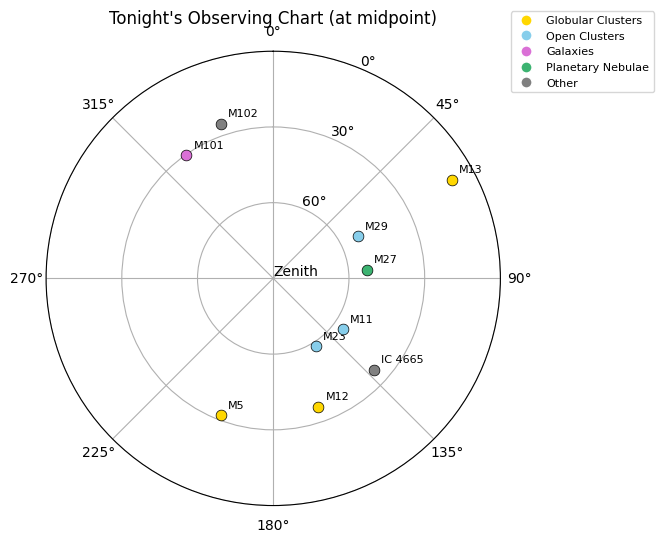

# 🔭 Tonight's Best Targets



---
## Recommended Observing

| # | Object | Category  | Magnitude | Direction| Distance | Altitude at 20:30:00 | Altitude at 21:30:00 | Transit Time | Constellation | Info | Fun Facts |
|---|--------|-----------|-----------|----------|----|------------|------------|-----------|---------------|------|-----------|
| 1 | **M102** | 🔭Other | `N/A` | NNW | `42,172,022 ly` | `66.8°` | `64.8°` | 20:29:50 | Draco | [Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-102/) | [Fun Facts](https://www.google.com/search?q=M102+astronomy+fun+facts) |
| 2 | **IC 4665** | 🔭Other | `N/A` | SE | `N/A` | `43.3°` | `53.8°` | 23:13:56 | Ophiucus | [Info](https://simbad.u-strasbg.fr/simbad/sim-id?Ident=IC+4665) | [Fun Facts](https://www.google.com/search?q=IC+4665+astronomy+fun+facts) |
| 3 | **M23** | ⭐Open Clusters | `5.5` | SSE | `N/A` | `23.7°` | `31.7°` | 23:24:48 | Sagittarius | [Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-23/) | [Fun Facts](https://www.google.com/search?q=M23+astronomy+fun+facts) |
| 4 | **M13** | ✨Globular Clusters | `5.8` | ENE | `26,092 ly` | `69.2°` | `81.0°` | 22:08:54 | Hercules | [Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-13/) | [Fun Facts](https://www.google.com/search?q=M13+astronomy+fun+facts) |
| 5 | **M11** | ⭐Open Clusters | `5.8` | SE | `N/A` | `23.3°` | `34.2°` | 00:18:32 | Scutum | [Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-11/) | [Fun Facts](https://www.google.com/search?q=M11+astronomy+fun+facts) |
| 6 | **M5** | ✨Globular Clusters | `6.0` | SSW | `25,407 ly` | `59.3°` | `57.9°` | 20:46:29 | Serpens | [Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-5/) | [Fun Facts](https://www.google.com/search?q=M5+astronomy+fun+facts) |
| 7 | **M12** | ✨Globular Clusters | `6.1` | SSE | `16,307 ly` | `47.5°` | `53.9°` | 22:14:58 | Ophiucus | [Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-12/) | [Fun Facts](https://www.google.com/search?q=M12+astronomy+fun+facts) |
| 8 | **M29** | ⭐Open Clusters | `6.6` | ENE | `N/A` | `26.4°` | `37.6°` | 01:50:39 | Cygnus | [Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-29/) | [Fun Facts](https://www.google.com/search?q=M29+astronomy+fun+facts) |
| 9 | **M27** | 🪐Planetary Nebulae | `7.4` | E | `N/A` | `24.7°` | `37.2°` | 01:26:35 | Vulpecula | [Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-27/) | [Fun Facts](https://www.google.com/search?q=M27+astronomy+fun+facts) |
| 10 | **M101** | 🌌Galaxies | `7.9` | NW | `21,852,478 ly` | `65.8°` | `59.7°` | 19:27:00 | Ursa Major | [Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-101/) | [Fun Facts](https://www.google.com/search?q=M101+astronomy+fun+facts) |






# --- All Retrieved Targets ---


## ✨ Globular Clusters
---
### **M13** — *Hercules Globular Cluster*
- **Magnitude:** `5.8` | **Alt (Start):** `69.2°` | **Alt (Midpoint):** `81.0°` | **Transit:** `2026-07-05 22:08:54`
- **Constellation:** Hercules
- **Distance:** 26,092 ly
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-13/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M13+astronomy+fun+facts)

### **M92**
- **Magnitude:** `6.5` | **Alt (Start):** `61.6°` | **Alt (Midpoint):** `71.9°` | **Transit:** `2026-07-05 22:44:13`
- **Constellation:** Hercules
- **Distance:** 29,125 ly
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-92/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M92+astronomy+fun+facts)

### **M3**
- **Magnitude:** `6.4` | **Alt (Start):** `72.3°` | **Alt (Midpoint):** `59.6°` | **Transit:** `2026-07-06 19:06:13`
- **Constellation:** Canes Venatici
- **Distance:** 32,615 ly
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-3/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M3+astronomy+fun+facts)

### **M5**
- **Magnitude:** `6.0` | **Alt (Start):** `59.3°` | **Alt (Midpoint):** `57.9°` | **Transit:** `2026-07-05 20:46:29`
- **Constellation:** Serpens
- **Distance:** 25,407 ly
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-5/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M5+astronomy+fun+facts)

### **M12**
- **Magnitude:** `6.1` | **Alt (Start):** `47.5°` | **Alt (Midpoint):** `53.9°` | **Transit:** `2026-07-05 22:14:58`
- **Constellation:** Ophiucus
- **Distance:** 16,307 ly
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-12/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M12+astronomy+fun+facts)

## ⭐ Open Clusters
---
### **M29**
- **Magnitude:** `6.6` | **Alt (Start):** `26.4°` | **Alt (Midpoint):** `37.6°` | **Transit:** `2026-07-06 01:50:39`
- **Constellation:** Cygnus
- **Distance:** N/A
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-29/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M29+astronomy+fun+facts)

### **M11** — *Amas de l'Ecu de Sobieski*
- **Magnitude:** `5.8` | **Alt (Start):** `23.3°` | **Alt (Midpoint):** `34.2°` | **Transit:** `2026-07-06 00:18:32`
- **Constellation:** Scutum
- **Distance:** N/A
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-11/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M11+astronomy+fun+facts)

### **M23**
- **Magnitude:** `5.5` | **Alt (Start):** `23.7°` | **Alt (Midpoint):** `31.7°` | **Transit:** `2026-07-05 23:24:48`
- **Constellation:** Sagittarius
- **Distance:** N/A
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-23/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M23+astronomy+fun+facts)

### **M18**
- **Magnitude:** `6.9` | **Alt (Start):** `21.5°` | **Alt (Midpoint):** `30.5°` | **Transit:** `2026-07-05 23:47:36`
- **Constellation:** Sagittarius
- **Distance:** N/A
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-18/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M18+astronomy+fun+facts)

## 🔭 Other
---
### **M102**
- **Magnitude:** `N/A` | **Alt (Start):** `66.8°` | **Alt (Midpoint):** `64.8°` | **Transit:** `2026-07-06 20:29:50`
- **Constellation:** Draco
- **Distance:** 42,172,022 ly
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-102/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M102+astronomy+fun+facts)

### **IC 4665**
- **Magnitude:** `N/A` | **Alt (Start):** `43.3°` | **Alt (Midpoint):** `53.8°` | **Transit:** `2026-07-05 23:13:56`
- **Constellation:** Ophiucus
- **Distance:** N/A
- **Database Info:** [More Info](https://simbad.u-strasbg.fr/simbad/sim-id?Ident=IC+4665)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=IC+4665+astronomy+fun+facts)

### **NGC 6633**
- **Magnitude:** `N/A` | **Alt (Start):** `35.8°` | **Alt (Midpoint):** `47.5°` | **Transit:** `2026-07-05 23:54:37`
- **Constellation:** Ophiucus
- **Distance:** N/A
- **Database Info:** [More Info](https://simbad.u-strasbg.fr/simbad/sim-id?Ident=NGC+6633)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=NGC+6633+astronomy+fun+facts)

### **NGC 6811**
- **Magnitude:** `N/A` | **Alt (Start):** `36.9°` | **Alt (Midpoint):** `47.2°` | **Transit:** `2026-07-06 01:03:58`
- **Constellation:** Cygnus
- **Distance:** N/A
- **Database Info:** [More Info](https://simbad.u-strasbg.fr/simbad/sim-id?Ident=NGC+6811)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=NGC+6811+astronomy+fun+facts)

### **NGC 6819**
- **Magnitude:** `N/A` | **Alt (Start):** `34.7°` | **Alt (Midpoint):** `46.0°` | **Transit:** `2026-07-06 01:08:06`
- **Constellation:** Cygnus
- **Distance:** N/A
- **Database Info:** [More Info](https://simbad.u-strasbg.fr/simbad/sim-id?Ident=NGC+6819)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=NGC+6819+astronomy+fun+facts)

## 🪐 Planetary Nebulae
---
### **M27** — *Dumbbell Nebula*
- **Magnitude:** `7.4` | **Alt (Start):** `24.7°` | **Alt (Midpoint):** `37.2°` | **Transit:** `2026-07-06 01:26:35`
- **Constellation:** Vulpecula
- **Distance:** N/A
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-27/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M27+astronomy+fun+facts)

## 🌌 Galaxies
---
### **M101**
- **Magnitude:** `7.9` | **Alt (Start):** `65.8°` | **Alt (Midpoint):** `59.7°` | **Transit:** `2026-07-06 19:27:00`
- **Constellation:** Ursa Major
- **Distance:** 21,852,478 ly
- **Database Info:** [More Info](https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-101/)

- **Fun Facts:** [Fun Facts](https://www.google.com/search?q=M101+astronomy+fun+facts)


In [ ]:
# @title Press Play to View Output (Wait time: ~2 Min)
# INSTANTIATE SCHEDULER INSTANCE
scheduler = dome_scheduler()

# RETRIEVE LIST - ENTER START AND END PARAMETERS HERE
objects = scheduler.view_sky(
    start_iso=start_iso,
    end_iso= end_iso,
    target_names = target_names, # Set to `None` when retrieving new list
    hide_objects_below_min_altitude=hide_objects_below_min_altitude, # Set to False (uncheck box) to view objects with altitude < min_altitude.
    min_altitude=min_altitude,
    max_magnitude=max_magnitude,
    show_all_acquired_targets = show_all_acquired_targets,
    sort_by = sort_by)
